In [1]:
import numpy as np
import random
from cmath import sqrt, pi, sin, cos, exp

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector,Operator
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere
from qiskit_aer import Aer

In [2]:
rot_gates = ["rx", "ry", "rz"]
unitary_gates = ["u1", "u2", "u3"]
single_gates = ["id", "x", "y", "z", "t", "tdg", "s", "sdg", "h"] + rot_gates
oneq_gates = single_gates + unitary_gates
control_gates = ["cx", "cy", "cz", "ch"]
twoq_gates = control_gates + ["swap"]
all_gates = oneq_gates + twoq_gates
start_states = ["1", "+", "-", "R", "L", "r", "d"]
valid_start = ["0"] + start_states

Available gates: ['id', 'x', 'y', 'z', 't', 'tdg', 's', 'sdg', 'h', 'rx', 'ry', 'rz', 'u1', 'u2', 'u3', 'cx', 'cy', 'cz', 'ch', 'swap']

Unitary for the cx gate:
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]

 Initial vector for |0⟩:
[1 0]

 Circuit:
-----------
     ┌───┐
q_0: ┤ X ├
     └─┬─┘
q_1: ──■──
          

 State Vector
-------------
[1.+0.j 0.+0.j 0.+0.j 0.+0.j]


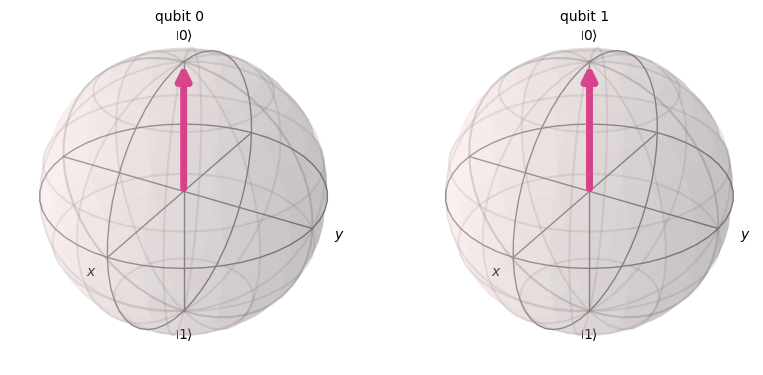

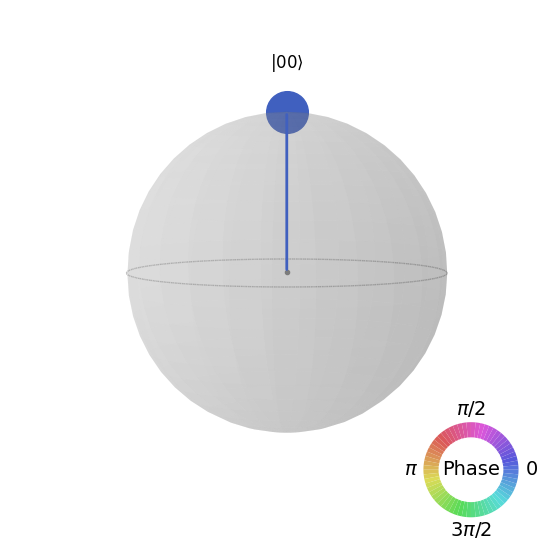

Available gates: ['id', 'x', 'y', 'z', 't', 'tdg', 's', 'sdg', 'h', 'rx', 'ry', 'rz', 'u1', 'u2', 'u3', 'cx', 'cy', 'cz', 'ch', 'swap']
Invalid input, try again.


In [ ]:
def get_psi(circuit):
    return Statevector.from_instruction(circuit)

def get_unitary(circuit):
    unitary = Operator(circuit)
    return unitary.data

def create_circuit(n_qubits, start):
    if start == "1":
        initial_vector = [0,1]
    elif start == "+":
        initial_vector = [1/sqrt(2), 1/sqrt(2)]
    elif start == "-":
        initial_vector = [1/sqrt(2), -1/sqrt(2)]
    elif start == "R":
        initial_vector = [1/sqrt(2), 1j/sqrt(2)]
    elif start == "L":
        initial_vector = [1/sqrt(2), -1j/sqrt(2)]
    elif start == "r":
        theta = random.random() * pi
        phi = random.random() * 2 * pi
        initial_vector = [cos(theta/2), exp(phi*1j) * sin(theta/2)]
    elif start == "d":
        initial_vector = [cos(start_theta/2), exp(start_phi*1j) * sin(start_theta/2)]
    else:
        initial_vector = [1,0]
    
    
    if start != "n":
        print(f"\n Initial vector for |{start}⟩:")
        print(np.around(initial_vector, decimals=3))
        
    circuit = QuantumCircuit(n_qubits)
    if start in start_states:
        circuit.prepare_state(initial_vector, n_qubits-1)
    
    return circuit

def qgate_out(circuit,start):
    psi = get_psi(circuit)
    if start != "n":
        print("\n Circuit:")
        print("-----------")
        print(circuit.draw())
        print("\n State Vector")
        print("-------------")
        print(np.around(psi.data, decimals=3))
        display(plot_bloch_multivector(psi))
        
        if circuit.num_qubits > 1:
            display(plot_state_qsphere(psi))
        return psi   
    
def qgate(gate_name, start):
    num_qubits = 1 if gate_name in oneq_gates else 2
    circuit = create_circuit(num_qubits, start)
    
    if gate_name in oneq_gates:
        target = 0
        if gate_name == "rx": circuit.rx(float(theta), target)
        elif gate_name == "ry":circuit.ry(float(theta), target)
        elif gate_name == "rz": circuit.rz(float(phi),target)
        elif gate_name == "h": circuit.h(target)
        elif gate_name == "x": circuit.x(target)
        elif gate_name == "y": circuit.y(target)
        elif gate_name == "z": circuit.z(target)
        elif gate_name == "id": circuit.id(target)
        elif gate_name == "s": circuit.s(target)
        elif gate_name == "sdg": circuit.sdg(target)
        elif gate_name == "t": circuit.t(target)
        elif gate_name == "tdg": circuit.tdg(target)
        elif gate_name == "u1":circuit.u(0,0,float(phi),target)
        elif gate_name == "u2":circuit.u(pi/2, float(phi),float(lam),target)
        elif gate_name == "u3":circuit.u(float(theta),float(phi),float(lam),target)
    
    else:
        if gate_name == "cx":circuit.cx(1,0)
        elif gate_name == "cy": circuit.cy(1, 0)
        elif gate_name == "cz": circuit.cz(1, 0)
        elif gate_name == "ch": circuit.ch(1, 0)
        elif gate_name == "swap": circuit.swap(0, 1)

    return circuit
        
def main():
    global phi,theta,lam,start_theta,start_phi,all_gates
    phi,theta,lam = 0.0,0.0,0.0
    gate = ""
    
        
    while gate != "exit":
        start = input("Start state (0, 1, +, -, R, L, r, d): ")
        if start == "d":
            start_theta = float(input("Enter start θ: "))
            start_phi = float(input("Enter start φ: "))
            
        print("Available gates:", all_gates)
        gate = input("Enter a gate or 'type exit':")
        
        if gate in ["rx", "ry", "u3"]:
            theta = input("Enter rotation (θ): ")
        if gate in ["u1", "u2", "u3", "rz"]:
            phi = input("Enter rotation (φ): ")
        if gate in ["u2", "u3"]:
            lam = input("Enter rotation (λ): ")
            
        if gate in all_gates and start in valid_start:
            temp_qc = qgate(gate, "n")
            print(f"\nUnitary for the {gate} gate:")
            print(np.around(Operator(temp_qc).data, decimals=3))
            
           
            qc = qgate(gate, start)
            qgate_out(qc, start)
        else:
            print("Invalid input, try again.")

if __name__ == '__main__':
    main()
        